# Industrial Predictive Maintenance - Data Preprocessing

This notebook prepares industrial sensor data for machine learning by performing feature encoding, train-test splitting, and preprocessing for predictive maintenance modeling.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import LabelEncoder,StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score,ConfusionMatrixDisplay

## Loading Processed Dataset

The processed dataset generated during exploratory data analysis is loaded for machine learning preparation.

The dataset already includes:
- Cleaned operational features
- Engineered industrial indicators
- Removed leakage variables
- Selected modeling features

In [2]:
df = pd.read_csv('../data/processed_ai4i.csv')

## Feature Encoding

The product quality type feature contains ordered categorical values:
- L → Low quality → 0
- M → Medium quality → 1
- H → High quality → 2

Since the categories possess meaningful operational ordering, ordinal encoding is used instead of nominal encoding.

This preserves the relative quality hierarchy while preparing the feature for machine learning models.

In [3]:
df['Type'] = df['Type'].map({"L":0,"M":1,"H":2})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  int64  
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   temp_diff                10000 non-null  float64
 7   estimated_power          10000 non-null  float64
 8   Machine failure          10000 non-null  int64  
dtypes: float64(5), int64(4)
memory usage: 703.3 KB


## Multicollinearity Analysis

The dataset contains both raw operational variables and engineered industrial indicators.

Features such as:
- temperature difference
- estimated mechanical power

are derived from existing sensor variables and may introduce multicollinearity in linear machine learning models.

This section evaluates whether redundant features should be retained or removed for improved model stability and interpretability.

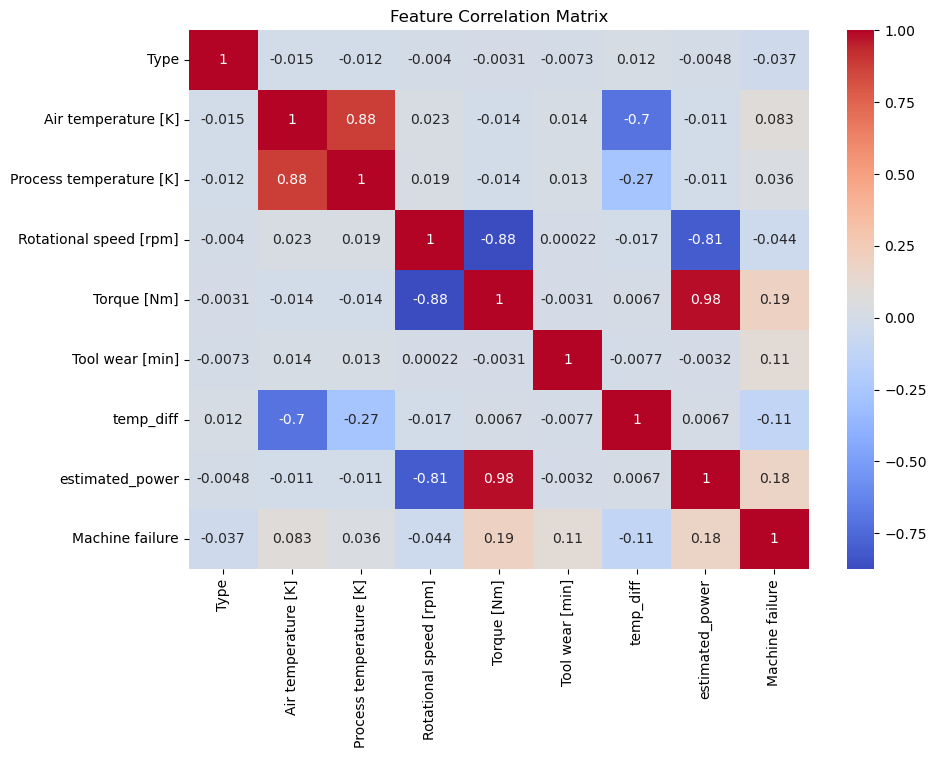

In [4]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Matrix')

plt.show()

## Correlation Analysis Insights

Correlation analysis reveals strong relationships between several raw operational variables and engineered industrial indicators.

Key observations:
- Torque and estimated mechanical power show extremely high positive correlation (0.978)
- Rotational speed and estimated power exhibit strong negative correlation (-0.806)
- Air temperature and process temperature are strongly correlated (0.876)
- Air temperature and temperature difference also display significant inverse correlation (-0.700)

These relationships indicate the presence of multicollinearity, particularly important for linear machine learning models such as Logistic Regression.

Since engineered features are derived from raw operational variables, retaining all correlated features together may:
- destabilize linear model coefficients
- reduce interpretability
- increase convergence difficulty

To address this:
- Reduced feature sets will be explored for linear models
- Full feature sets will be retained for tree-based models, which are less sensitive to multicollinearity

This approach enables comparison between:
- compact physics-informed feature representations
- full operational sensor representations

## Feature and Target Separation

The dataset is separated into:
- input features (`X`)
- target variable (`y`)

The target variable:
- `Machine failure`

represents whether the machine experienced operational failure under the recorded process conditions.

Separating features and target before preprocessing ensures cleaner machine learning workflow and prevents unintended data leakage during later experimentation stages.

## Train-Test Split

The dataset is divided into training and testing subsets for model evaluation.

A stratified split is used to preserve the original machine failure distribution across both sets due to the strong class imbalance present in the dataset.

The split is performed before feature subset creation to maintain proper machine learning workflow and ensure fair comparison between different feature configurations.

In [5]:
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

## Feature Set Preparation

Two feature configurations are prepared for comparative modeling.

### Full Feature Set
Contains:
- raw operational sensor variables
- engineered industrial indicators

This configuration is intended primarily for:
- Decision Trees
- Random Forest
- other tree-based models

which are generally less sensitive to multicollinearity.

### Reduced Feature Set
Contains:
- selected engineered industrial indicators
- lower redundancy between variables

This configuration is intended for:
- Logistic Regression
- linear machine learning models

where multicollinearity may negatively impact coefficient stability and interpretability.

This approach enables comparison between:
- complete operational sensor representation
- compact physics-informed feature representation

In [6]:
full_feature_cols = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'temp_diff',
    'estimated_power'
]

X_full_train = X_train[full_feature_cols]
X_full_test = X_test[full_feature_cols]

reduced_feature_cols = [
    'Type',
    'Tool wear [min]',
    'temp_diff',
    'estimated_power'
]

X_reduced_train = X_train[reduced_feature_cols]
X_reduced_test = X_test[reduced_feature_cols]

## Feature Scaling

Feature scaling is applied to the reduced feature set used for linear machine learning models.

Linear models such as Logistic Regression are sensitive to differences in feature magnitudes and variance, making scaling important for:
- stable optimization
- faster convergence
- improved coefficient behavior

The full feature set intended for tree-based models is not scaled, since tree algorithms are generally insensitive to feature magnitudes.

In [7]:
scaler = StandardScaler()

X_reduced_train_scaled = scaler.fit_transform(X_reduced_train)

X_reduced_test_scaled = scaler.transform(X_reduced_test)

## Baseline Modeling

Initial machine learning models are trained to establish baseline predictive performance for machine failure detection.

The objective of baseline modeling is to:
- evaluate predictive feasibility
- compare linear and tree-based approaches
- understand model behavior on industrial sensor data
- identify suitable evaluation metrics for imbalanced failure prediction

The following models will be explored:
- Logistic Regression
- Decision Tree
- Random Forest

In [8]:
clf1 = LogisticRegression(random_state=0)
clf2 = DecisionTreeClassifier(random_state=0)
clf3 = RandomForestClassifier(n_estimators=100,random_state=0)

clf1.fit(X_reduced_train_scaled,y_train)
clf2.fit(X_full_train,y_train)
clf3.fit(X_full_train,y_train)
y_pred1 = clf1.predict(X_reduced_test_scaled)

y_pred2 = clf2.predict(X_full_test)

y_pred3 = clf3.predict(X_full_test)

## Model Prediction and Evaluation

Predictions are generated using baseline machine learning models to evaluate their ability to detect machine failures from industrial sensor data.

Since the dataset contains strong class imbalance, evaluation focuses not only on accuracy but also on:
- Precision
- Recall
- F1-score

In predictive maintenance systems, recall is particularly important because failing to detect an actual machine failure can result in:
- unplanned downtime
- operational losses
- equipment damage

In [9]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],

    'Accuracy': [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2),
        accuracy_score(y_test, y_pred3)
    ],
    
    'Precision': [
        precision_score(y_test, y_pred1),
        precision_score(y_test, y_pred2),
        precision_score(y_test, y_pred3)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred1),
        recall_score(y_test, y_pred2),
        recall_score(y_test, y_pred3)
    ],
    
    'F1 Score': [
        f1_score(y_test, y_pred1),
        f1_score(y_test, y_pred2),
        f1_score(y_test, y_pred3)
    ],
    
    'ROC-AUC': [
        roc_auc_score(y_test, clf1.predict_proba(X_reduced_test_scaled)[:,1]),
        
        roc_auc_score(y_test, clf2.predict_proba(X_full_test)[:,1]),
        
        roc_auc_score(y_test, clf3.predict_proba(X_full_test)[:,1])
    ]
})

results = results.round(3)

results = results.sort_values(by='Recall',ascending=False)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,0.984,0.774,0.765,0.769,0.878
2,Random Forest,0.988,0.937,0.694,0.797,0.952
0,Logistic Regression,0.967,1.000,0.035,0.068,0.798


## Initial Model Performance Insights

Tree-based models demonstrate stronger predictive capability compared to Logistic Regression, particularly in identifying nonlinear operational failure patterns.

Random Forest achieves the best balance between:
- recall
- precision
- overall F1-score

indicating improved ability to capture interaction-driven machine failure behavior from industrial sensor data.

<Figure size 500x400 with 0 Axes>

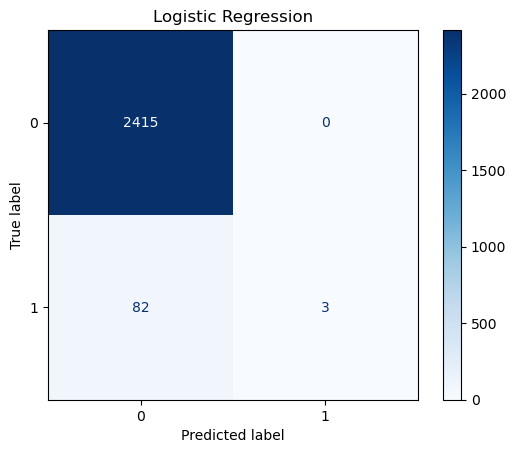

<Figure size 500x400 with 0 Axes>

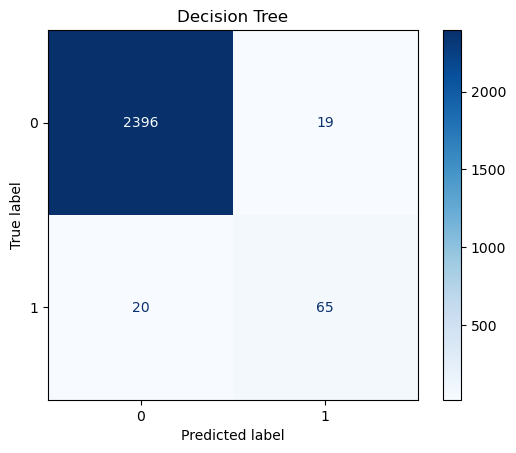

<Figure size 500x400 with 0 Axes>

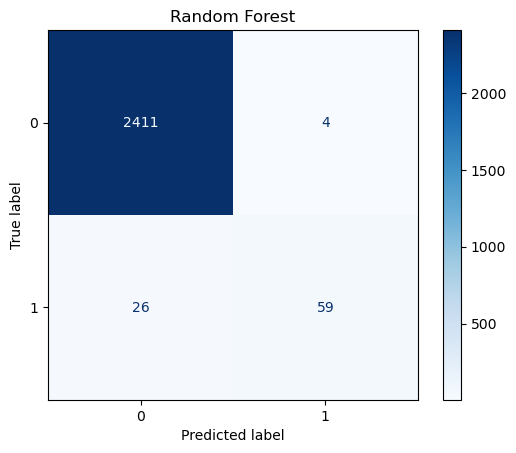

In [10]:
models = [
    ('Logistic Regression', clf1, X_reduced_test_scaled),
    ('Decision Tree', clf2, X_full_test),
    ('Random Forest', clf3, X_full_test)
]

for name, model, X_test_data in models:
    
    plt.figure(figsize=(5,4))
    
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_data,
        y_test,
        cmap='Blues'
    )
    
    plt.title(name)
    plt.show()

## Cross Validation

Cross validation is performed to evaluate model stability across multiple data splits.

This helps ensure that model performance is not dependent on a single train-test partition and provides a more reliable estimate of generalization performance.

In [11]:
cv_lr = cross_val_score(
    clf1,
    X_reduced_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)


cv_dt = cross_val_score(
    clf2,
    X_full_train,
    y_train,
    cv=5,
    scoring='f1'
)


cv_rf = cross_val_score(
    clf3,
    X_full_train,
    y_train,
    cv=5,
    scoring='f1'
)

cv_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    
    'Mean F1 Score': [
        cv_lr.mean(),
        cv_dt.mean(),
        cv_rf.mean()
    ]
})

cv_results.round(3)
cv_results

,Model,Mean F1 Score
0,Logistic Regression,0.096467
1,Decision Tree,0.766820
2,Random Forest,0.821210


## Preprocessing and Baseline Modeling Summary

Key preprocessing and baseline modeling tasks completed:

- Processed industrial sensor dataset prepared
- Ordinal encoding applied to product quality categories
- Full and reduced feature configurations created
- Multicollinearity analyzed through correlation analysis
- Feature scaling applied for linear models
- Baseline machine learning models trained
- Performance evaluated using imbalance-aware metrics
- Cross validation performed for model stability assessment

Initial results indicate that tree-based models are better suited for capturing the nonlinear operational behavior associated with industrial machine failures.

In [14]:
full_feature_dataset = df[full_feature_cols + ['Machine failure']]

reduced_feature_dataset = df[reduced_feature_cols + ['Machine failure']]

full_feature_dataset = pd.concat(
    [X_train[full_feature_cols], y_train],
    axis=1
)

full_feature_dataset.to_csv(
    "../data/full_feature_dataset.csv",
    index=False
)

reduced_feature_dataset = pd.concat(
    [X_train[reduced_feature_cols], y_train],
    axis=1
)

reduced_feature_dataset.to_csv(
    "../data/reduced_feature_dataset.csv",
    index=False
)